# Analizando las ventas de piezas de motocicleta

## Resumen del proyecto

Este proyecto analiza las ventas mayoristas de una empresa dedicada a la comercialización de piezas para motocicletas. La compañía opera a través de tres almacenes regionales y ofrece distintos métodos de pago, cada uno con una comisión asociada que impacta directamente en los ingresos obtenidos por cada venta.

El objetivo principal fue calcular los ingresos netos generados por cada línea de producto, agrupando los resultados por mes y almacén para identificar patrones de comportamiento, diferencias regionales y oportunidades de negocio. Para ello se utilizaron consultas SQL para la extracción y transformación de los datos, complementadas con visualizaciones desarrolladas en Python para facilitar la interpretación de los resultados.

> **Nota:** Este proyecto representa una primera fase de análisis enfocada en la obtención, transformación y exploración de datos. Futuras etapas podrían incorporar dashboards interactivos, análisis de rentabilidad y modelos predictivos para apoyar la toma de decisiones estratégicas.

## Introducción

Las empresas de distribución de refacciones necesitan comprender el desempeño de sus ventas para identificar oportunidades de crecimiento y optimizar la toma de decisiones. En este proyecto se analiza la información de ventas mayoristas de una empresa dedicada a la comercialización de piezas para motocicletas, considerando operaciones realizadas en tres almacenes durante el periodo de junio a agosto de 2021.

## Pregunta de negocio

¿Qué líneas de producto, almacenes y periodos generaron los mayores ingresos netos dentro del segmento de clientes mayoristas durante el periodo analizado?

## Objetivos

- Filtrar exclusivamente las ventas correspondientes al segmento Wholesale.
- Calcular los ingresos netos considerando las comisiones asociadas a cada método de pago.
- Agrupar los resultados por línea de producto, mes y almacén.
- Comparar el desempeño comercial entre los almacenes North, Central y West.
- Identificar tendencias de ventas durante el periodo analizado.

## Diccionario de datos

| Variable | Tipo de Dato | Descripción |
|-----------|-------------|-------------|
| order_number | VARCHAR | Identificador único de cada pedido realizado. |
| date | DATE | Fecha en la que se registró la venta. |
| warehouse | VARCHAR | Almacén desde donde se procesó el pedido (North, Central o West). |
| client_type | VARCHAR | Tipo de cliente que realizó la compra: Retail o Wholesale. |
| product_line | VARCHAR | Línea o categoría de producto vendida. |
| quantity | INT | Cantidad de unidades vendidas en el pedido. |
| unit_price | FLOAT | Precio unitario de cada producto en dólares. |
| total | FLOAT | Valor total de la venta antes de considerar comisiones. |
| payment | VARCHAR | Método de pago utilizado por el cliente (Credit Card, Cash o Transfer). |
| payment_fee | FLOAT | Comisión asociada al método de pago utilizado. |

## Metodología

El análisis se desarrolló utilizando SQL para la transformación de los datos y Python para la generación de visualizaciones.

El proceso consistió en:

- Comprender el problema de negocio.
- Identificar las variables relevantes para el análisis.
- Filtrar únicamente las ventas realizadas a clientes mayoristas.
- Calcular los ingresos netos considerando las comisiones de pago.
- Agrupar los resultados por línea de producto, mes y almacén.
- Analizar el comportamiento de los ingresos netos mediante visualizaciones.

> **Nota:** Este análisis busca convertir los datos de ventas en información accionable que facilite la identificación de oportunidades de mejora y apoye la toma de decisiones del negocio.

## Preparación de datos

In [1]:
# Importar librerías para manipulación de datos y consultas SQL
import duckdb
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Leer el conjunto de datos de ventas de piezas de motocycleta
df = pd.read_excel("../data/raw/motorcycle_parts_sales.xlsx")

#Vista previa del conjunto de datos
df.head()

,index,order_number,date,warehouse,client_type,product_line,quantity,unit_price,total,payment,payment_fee
0,0,N1,2021-06-01T00:00:00.000,North,Retail,Braking system,9,19.29,173.61,Cash,0.00
1,1,N2,2021-06-01T00:00:00.000,North,Retail,Suspension & traction,8,32.93,263.45,Credit card,0.03
2,4,N5,2021-06-01T00:00:00.000,North,Retail,Frame & body,6,45.44,272.61,Credit card,0.03
3,5,N6,2021-06-02T00:00:00.000,North,Retail,Frame & body,1,40.41,40.41,Credit card,0.03
4,6,N7,2021-06-02T00:00:00.000,North,Retail,Miscellaneous,6,20.28,121.66,Credit card,0.03


In [3]:
# Preparación y transformación de los datos
resultado = duckdb.sql("""
    WITH sales_month AS (
        SELECT
            product_line,
            -- Clasificación de las ventas por mes
            CASE
                WHEN date BETWEEN '2021-06-01' AND '2021-06-30' THEN 'June'
                WHEN date BETWEEN '2021-07-01' AND '2021-07-31' THEN 'July'
                WHEN date BETWEEN '2021-08-01' AND '2021-08-31' THEN 'August'
            END AS month,
            warehouse,
            total,
            payment_fee
        FROM df
        -- Filtrar únicamente las ventas mayoristas
        WHERE client_type = 'Wholesale'
    )
    -- Cálculo de ingresos netos por producto, mes y almacén
    SELECT
        product_line,
        month,
        warehouse,
        ROUND(SUM(total - payment_fee), 2) AS net_revenue
    FROM sales_month
    GROUP BY
        product_line,
        month,
        warehouse
    -- Ordenar resultados para facilitar su análisis
    ORDER BY
        product_line,
        month,
        net_revenue DESC;
""").df()

resultado

,product_line,month,warehouse,net_revenue
0,Braking system,August,Central,3039.41
1,Braking system,August,West,2500.67
2,Braking system,August,North,1770.84
3,Braking system,July,Central,3303.69
4,Braking system,July,West,3060.93
5,Braking system,July,North,2594.44
6,Braking system,June,Central,3684.89
7,Braking system,June,North,1487.77
8,Braking system,June,West,1212.75
9,Braking system,NaN,Central,474.96


In [4]:
# Filtrar ventas mayoristas
wholesale = df[df['client_type'] == 'Wholesale'].copy()

# Crear columna de mes
wholesale['month'] = pd.to_datetime(
    wholesale['date']
).dt.month_name()

# Calcular ingresos netos
wholesale['net_revenue'] = (
    wholesale['total']
    - wholesale['payment_fee']
)

# Orden lógico de los meses
month_order = ['June', 'July', 'August']

## Distribución de ingresos por línea de producto

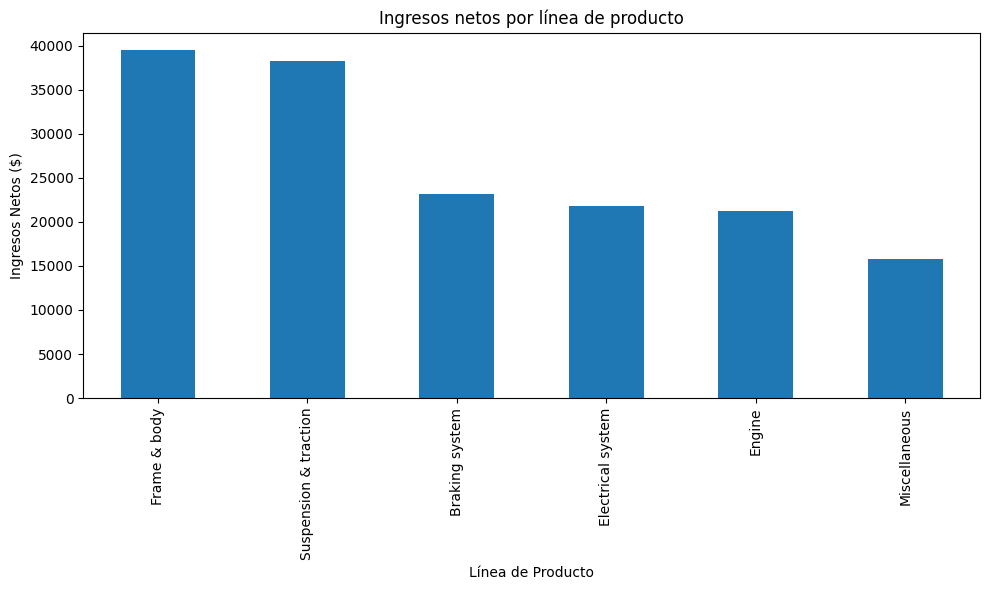

In [5]:
# Identificar qué líneas de productos generan más ingresos netos para la empresa.
product_revenue = (
    wholesale
    .groupby('product_line')['net_revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))

product_revenue.plot(kind='bar')

plt.title('Ingresos netos por línea de producto')
plt.xlabel('Línea de Producto')
plt.ylabel('Ingresos Netos ($)')

plt.tight_layout()
plt.show()

## Evolución de los ingresos por mes y almacén

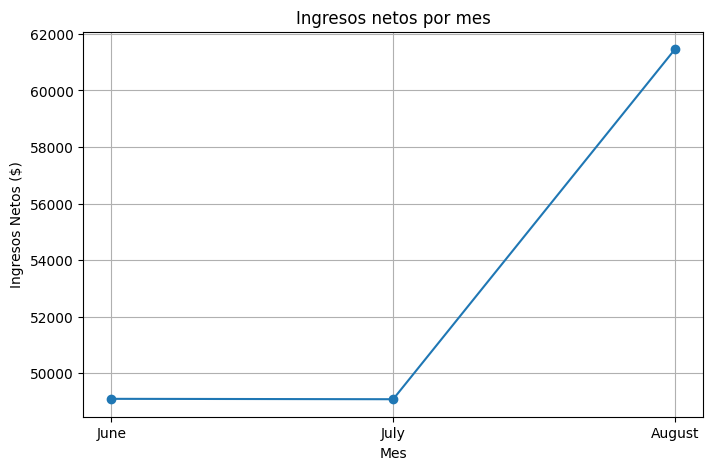

In [6]:
# Observa el desempeño de los diferentes almacenes para identificar cuál es el más rentable.
monthly_revenue = (
    wholesale
    .groupby('month')['net_revenue']
    .sum()
    .reindex(month_order)
)

plt.figure(figsize=(8,5))

plt.plot(
    monthly_revenue.index,
    monthly_revenue.values,
    marker='o'
)

plt.title('Ingresos netos por mes')
plt.xlabel('Mes')
plt.ylabel('Ingresos Netos ($)')

plt.grid(True)

plt.show()

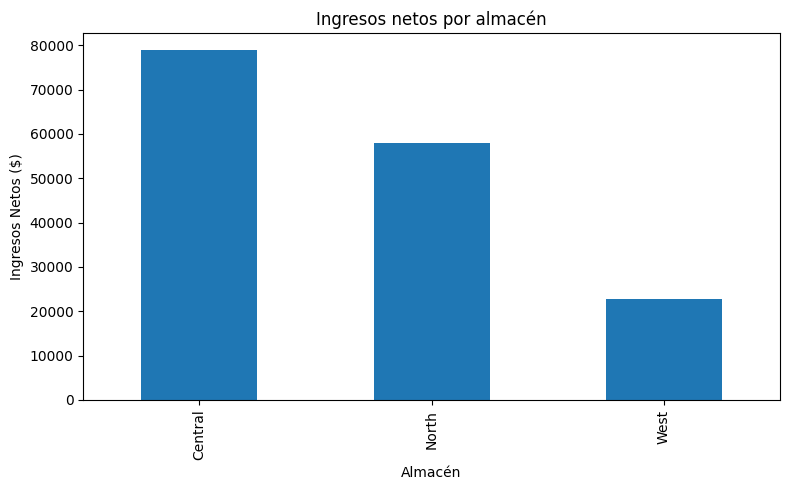

In [7]:
# Compara el desempeño de los diferentes almacenes para identificar cuál es el más rentable.
warehouse_revenue = (
    wholesale
    .groupby('warehouse')['net_revenue']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,5))

warehouse_revenue.plot(kind='bar')

plt.title('Ingresos netos por almacén')
plt.xlabel('Almacén')
plt.ylabel('Ingresos Netos ($)')

plt.tight_layout()
plt.show()

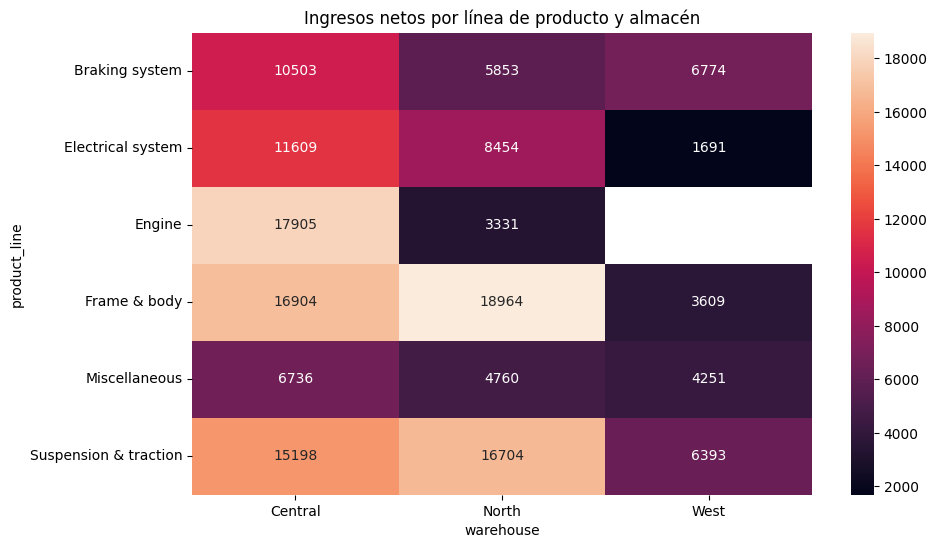

In [8]:
# Analiza la relación entre las líneas de productos y los almacenes para identificar patrones de ventas.
product_warehouse = wholesale.pivot_table(
    values='net_revenue',
    index='product_line',
    columns='warehouse',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))

sns.heatmap(
    product_warehouse,
    annot=True,
    fmt='.0f'
)

plt.title('Ingresos netos por línea de producto y almacén')

plt.show()

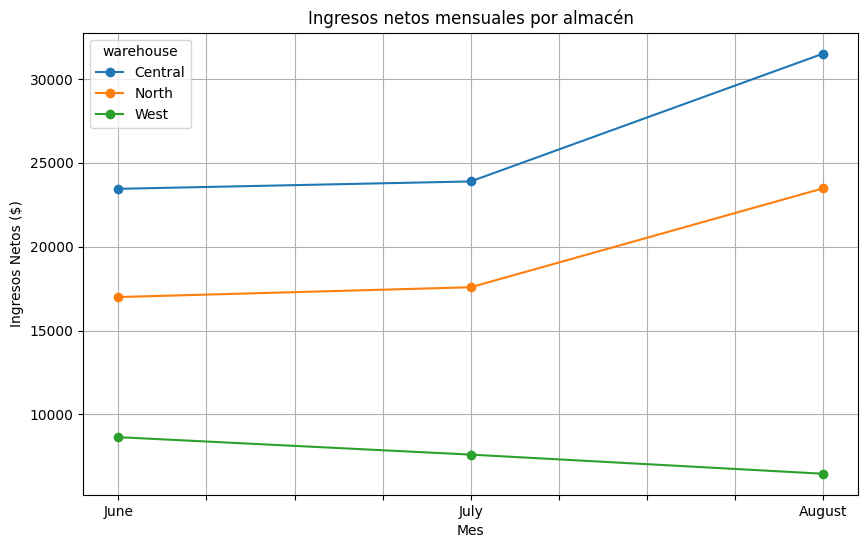

In [9]:
# Que almacén tiene el mejor desempeño en términos de ingresos netos a lo largo de los meses? Analiza la evolución mensual de los ingresos netos por almacén para identificar tendencias y patrones de desempeño.
monthly_wh = wholesale.pivot_table(
    values='net_revenue',
    index='month',
    columns='warehouse',
    aggfunc='sum'
)

monthly_wh = monthly_wh.reindex(month_order)

monthly_wh.plot(
    figsize=(10,6),
    marker='o'
)

plt.title('Ingresos netos mensuales por almacén')
plt.xlabel('Mes')
plt.ylabel('Ingresos Netos ($)')

plt.grid(True)

plt.show()

## Hallazgos principales

- Frame & Body fue la línea de producto con mayores ingresos netos, seguida de Suspension & Traction, consolidándose como las categorías con mejor desempeño durante el período analizado.
- El almacén Central generó la mayor cantidad de ingresos netos, mientras que West presentó el menor desempeño.
- El análisis de la relación entre líneas de producto y almacenes mostró una contribución consistente de las categorías Frame & Body y Suspension & Traction en los distintos almacenes.
- Los ingresos netos se mantuvieron relativamente estables entre junio y julio, registrando un crecimiento significativo en agosto.
- El incremento observado en agosto fue impulsado principalmente por los almacenes Central y North, mientras que West mostró una tendencia descendente.

## Conclusiones

Los resultados indican que las líneas Frame & Body y Suspension & Traction son los principales impulsores de ingresos netos dentro del segmento mayorista analizado. Asimismo, los almacenes Central y North concentran la mayor parte del desempeño comercial observado durante el período.

El crecimiento registrado en agosto sugiere un aumento en la actividad de ventas que merece un análisis más profundo para identificar los factores que lo impulsaron. En contraste, el desempeño de West representa una oportunidad para investigar posibles factores operativos, comerciales o de demanda que puedan estar limitando sus resultados.

## Recomendaciones

- Priorizar el seguimiento de las líneas Frame & Body y Suspension & Traction debido a su contribución al ingreso neto.
- Analizar las causas del crecimiento observado en agosto para identificar patrones replicables en períodos futuros.
- Investigar los factores que limitan el desempeño del almacén West.
- Complementar el análisis con métricas de volumen de ventas, márgenes y rentabilidad para obtener una visión más completa del negocio.